### libraries
`conda install dask`

made it work. needs a `compute()` call before any methods. no improvement in run time.


`pip install modin[all]`

has so many errors -- can't install the latest version using `pip`, dependencies are outdated.

`pip install polars-lts-cpu`

installed successfully, but has a read error in csv.

In [1]:
# import sys
# # # !conda remove --yes --prefix {sys.prefix} dask
# !{sys.executable} -m pip install numexpr --upgrade

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import timedelta
from scipy import stats
from scipy.spatial import ConvexHull

plt.rcParams.update({'font.size': 25})
plt.style.use('tableau-colorblind10')

In [3]:
EFF_VS_COST = 'eff' #'eff' or 'cost'
DIST = 'poisson' #uniform, gamma, poisson
seed = 42
rng = np.random.default_rng(seed)

In [4]:
# df = pd.read_csv('../Original-City-Repo/suppressed_sanitarian_features/30_dat_0.csv', parse_dates=["Inspection_Date"])
dtype_dict = {
    'Zip':'object',
    'American_Indian': 'float64',
    'BUSINESS_ACTIVITY_ID': 'object',
    'POLICE_DISTRICT': 'float64',
    'PRECINCT': 'float64',
    'WARD': 'float64',
    'ZIP_CODE': 'object',
    'timeSinceLast': 'float64'
}
df = pd.read_csv('./data/schenk/30_dat_18.csv', parse_dates=["Inspection_Date"], dtype=dtype_dict)

In [5]:
df.dtypes

Unnamed: 0                  int64
Inspection_ID               int64
Inspection_Date    datetime64[us]
DBA_Name                      str
AKA_Name                      str
                        ...      
heat_sanitation           float64
criticalFound               int64
Test                         bool
glm_pred                  float64
glm_pred_test             float64
Length: 99, dtype: object

In [6]:
def get_mean_inspection_time(df, filter_dict):
    test_df = df[df["Test"] == 1]
    test_df = test_df.sort_values(by=["glm_pred_test"], ascending=False)
    
    test_df["Simulated_Date"] = test_df["Inspection_Date"].copy().sort_values().values
    # earliest_date = test_df["Simulated_Date"].min()
    # test_df["Date_Difference"] = test_df["Simulated_Date"] - earliest_date
    latest_date = test_df["Simulated_Date"].max()
    test_df["Date_Difference"] = latest_date - test_df["Simulated_Date"]
    
    for key, val in filter_dict.items():
        test_df = test_df[test_df[key] == val]
    return test_df["Date_Difference"].mean()/pd.to_timedelta(1, unit='D') 

In [7]:
get_mean_inspection_time(df, {'criticalFound':True, 'sanitarian':'purple'})

52.7

In [8]:
df["sanitarian"].value_counts()/df.shape[0]

sanitarian
green     0.263511
orange    0.217401
blue      0.183963
yellow    0.160588
brown     0.106597
purple    0.067941
Name: count, dtype: float64

In [9]:
# # to do incluster sort
# df = df[df['sanitarian']=='orange']

### sanitarian capacity

we want to find out the unit amount of work done by each inspection, every day.

In [10]:
num_sanitarians = 35 #source: https://podtail.com/en/podcast/city-cast-chicago/-the-bear-got-it-wrong-here-s-how-health-inspectio/
total_inspections = df['Inspection_Date'].shape[0]
# num_days = df['Inspection_Date'].unique().shape[0]
num_days = (df['Inspection_Date'].max() - df['Inspection_Date'].min())/pd.to_timedelta(1, unit='D')

print(f"total inspection: {total_inspections}, number of days: {num_days}, number of sanitarians: {num_sanitarians}")
insp_per_sanitarian = total_inspections / num_sanitarians
print(f"inspections per sanitarian: {insp_per_sanitarian}")
insp_per_sanitarian_per_day = insp_per_sanitarian / num_days
print(f"inspections per sanitarian per day: {insp_per_sanitarian_per_day}")

insp_per_day = total_inspections / num_days
print(f"inspections per day: {insp_per_day}")
insp_per_day_per_sanitarian = insp_per_day / num_sanitarians
print(f"inspections per day per sanitarian: {insp_per_day_per_sanitarian}")

total inspection: 18781, number of days: 1155.0, number of sanitarians: 35
inspections per sanitarian: 536.6
inspections per sanitarian per day: 0.4645887445887446
inspections per day: 16.26060606060606
inspections per day per sanitarian: 0.4645887445887446


In [11]:
# params = stats.gamma.fit(insp_per_day_data)
# print(f"Estimated parameters (loc, scale): {params}")

In [12]:
d = df['Inspection_Date'].max() - df['Inspection_Date'].min()

In [13]:
total_inspections/(insp_per_day_per_sanitarian*2)

20212.5

In [14]:
def stochastic_rounding(x):
    x = np.maximum(x,0)
    a = np.floor(x)
    b = a + 1
    return (np.random.choice([a,b], p=[b-x, x-a]))

#### method 1

the method distributes the inspections per day equally across n-1 windows, and the remaining inspections on the last day.
source: https://numpy.org/doc/stable/reference/generated/numpy.array_split.html

In [15]:
# distributing equal inspections per day besides the last window using np.array_split()

def distribute_insp_dates_1(df, insp_per_day_per_sanitarian, n):
    sim_inps_per_day = (insp_per_day_per_sanitarian * n)
    total_insp_days = np.round(df.shape[0] / (sim_inps_per_day))
    last_date = df['Inspection_Date'].min()
    sim_dates_list = list()

    for chunk in np.array_split(np.arange(df.shape[0]), total_insp_days):
        sim_dates_list.extend(np.repeat(last_date, chunk.shape[0]))
        last_date = last_date + pd.Timedelta(days=1)
    return np.array(sim_dates_list)

#### method 2

the method distributes the inspections per day stochastically by rounding a non-integer value up and down, randomly.
source: https://en.wikipedia.org/wiki/Rounding#Stochastic_rounding

In [16]:
# distributing inspections per day using stochastic rounding

def distribute_insp_dates_2(df, insp_per_day_per_sanitarian, n):
    sim_inps_per_day = (insp_per_day_per_sanitarian * n)
    total_insp_days = np.round(df.shape[0] / (sim_inps_per_day))
    last_date = df['Inspection_Date'].min()
    sim_dates_list = list()

    while len(sim_dates_list) < df.shape[0]:
        sim_dates_list.extend(np.repeat(last_date, stochastic_rounding(sim_inps_per_day)))
        last_date = last_date + pd.Timedelta(days=1)
    sim_dates_list = sim_dates_list[:df.shape[0]]
    return np.array(sim_dates_list[:df.shape[0]])

#### method 3

find the distribution that best fits inspections per day and use that to sample more data

In [17]:
# calc std dev
mean_diff_sqd = 0
insp_per_day_data = list()
for i, (grp_id, grped_df) in enumerate(df.groupby(by=['Inspection_Date'])):
    mean_diff_sqd += np.square(insp_per_day - len(grped_df))
    insp_per_day_data.append(len(grped_df))
insp_var = mean_diff_sqd / i
print(insp_var, np.mean(insp_per_day_data), i)

260.87006159414443 27.41751824817518 684


         sumsquare_error          aic          bic    kl_div  ks_statistic  \
gamma           0.030370  5314.995334  5328.583590  7.432673      0.030522   
lognorm         0.030370  5314.998675  5328.586931  7.433085      0.030188   
norm            0.030371  5313.177544  5322.236382  7.430450      0.033042   
expon           0.050585  5859.417483  5868.476321  7.592150      0.278487   

            ks_pvalue  
gamma    5.358500e-01  
lognorm  5.500674e-01  
norm     4.338546e-01  
expon    1.819590e-47  
{'gamma': {'a': np.float64(2811.7756594152124), 'loc': np.float64(-591.0111810570447), 'scale': np.float64(0.21994172136268597)}}
{'gamma': (np.float64(2811.7756594152124), np.float64(-591.0111810570447), np.float64(0.21994172136268597)), 'lognorm': (np.float64(0.014631614332495223), -769.6351405269406, np.float64(796.9673462618338)), 'expon': (1.0, 26.41751824817518), 'norm': (np.float64(27.41751824817518), np.float64(11.662441417915433))}


2026-05-11 21:51:23.529 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=0.030370, AIC=5315.00, KS=0.0305
2026-05-11 21:51:23.549 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=0.030370, AIC=5315.00, KS=0.0302
2026-05-11 21:51:23.549 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=0.050585, AIC=5859.42, KS=0.2785
2026-05-11 21:51:23.550 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=0.030371, AIC=5313.18, KS=0.0330


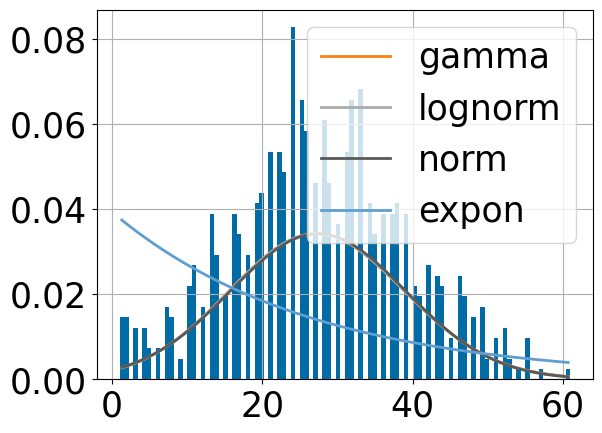

In [18]:
from fitter import Fitter
from fitter import get_distributions

dist_fitter = Fitter(insp_per_day_data, distributions=["gamma", "lognorm", "expon", "norm"])
# dist_fitter = Fitter(insp_per_day_data, distributions=get_distributions())

 # Fit the distributions
dist_fitter.fit()

# Print a summary to find the best fit
# This shows the best distributions ordered by the sum of squares error
print(dist_fitter.summary())

# Get the best fitting distribution name and parameters
print(dist_fitter.get_best(method='sumsquare_error'))
print(dist_fitter.fitted_param)

In [19]:
# print(np.round(rng.gamma(shape, scale, size=10)))
a, loc, scale = dist_fitter.fitted_param['gamma']
print(stats.gamma.rvs(a, loc=loc, scale=scale, size=10, random_state=rng))
print(stochastic_rounding(stats.gamma.rvs(a, loc=loc/(num_sanitarians-2), scale=scale/(num_sanitarians-2), size=None, random_state=rng)))
# print(np.round(rng.gamma(a/35, scale, size=10)))

[30.90269919 36.13538245  4.86728589 28.8343541  27.14636962 37.6546044
 28.11265188 32.81040676 31.65262382 37.64343018]
1.0


In [20]:
a, loc, scale = stats.gamma.fit(insp_per_day_data, floc=0)
print(a, loc, scale)
print(stats.gamma.rvs(a, loc=loc, scale=scale, size=10, random_state=rng))

3.750950814918586 0 7.30948487490905
[45.41028184 19.62857626 32.88653917 30.98358549 18.67877495 34.26339755
 23.47268177 15.41407353 36.43065363 12.26165746]


In [21]:
# distributing inspections per day using gamma distribution

def distribute_insp_dates_3(df, insp_per_day_per_sanitarian, n):
    if num_sanitarians-n > 0:
        loc_per_sanitarian = (loc/(num_sanitarians))*n
        scale_per_sanitarian = (scale/(num_sanitarians))*n
    else:
        loc_per_sanitarian = loc
        scale_per_sanitarian = scale
    last_date = df['Inspection_Date'].min()
    sim_dates_list = list()
    
    while len(sim_dates_list) < df.shape[0]:
        num_inspections_this_day = stochastic_rounding(stats.gamma.rvs(a, loc=loc_per_sanitarian, scale=scale_per_sanitarian, size=None, random_state=rng))
        # print(f"{num_inspections_this_day=}, {loc_per_sanitarian=}, {scale_per_sanitarian=}")
        sim_dates_list.extend(np.repeat(last_date, num_inspections_this_day))
        last_date = last_date + pd.Timedelta(days=1)
    sim_dates_list = sim_dates_list[:df.shape[0]]
    return np.array(sim_dates_list[:df.shape[0]])

#### method 4 -- Poisson Distribution 

In [22]:
lambda_hat = np.mean(insp_per_day_data)

In [23]:
print(stats.poisson.rvs(lambda_hat, loc=0, size=10, random_state=rng))

[33 26 30 22 32 31 27 21 30 28]


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/var/folders/d9/770yh1d13_jgblbmf5m8q2yh0000gn/T/ipykernel_69103/2113012395.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(bin_centers, pmf_fitted, 'r-', lw=2, label=f'Fitted Poisson ($\lambda$={lambda_hat:.2f})')


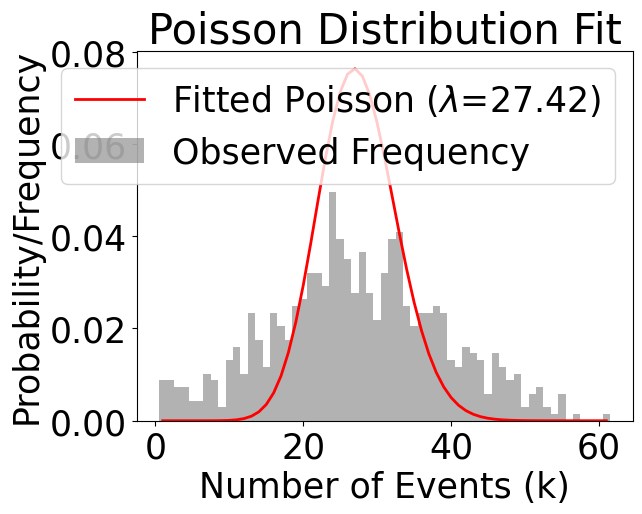

In [24]:
bins = np.arange(min(insp_per_day_data), max(insp_per_day_data) + 1.5) - 0.5
hist, edges = np.histogram(insp_per_day_data, bins=bins, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2

pmf_fitted = stats.poisson.pmf(bin_centers, mu=lambda_hat)

plt.bar(bin_centers, hist, width=1, color='gray', alpha=0.6, label='Observed Frequency')
plt.plot(bin_centers, pmf_fitted, 'r-', lw=2, label=f'Fitted Poisson ($\lambda$={lambda_hat:.2f})')
plt.xlabel('Number of Events (k)')
plt.ylabel('Probability/Frequency')
plt.title('Poisson Distribution Fit')
plt.legend()
plt.show()

In [25]:
# distributing inspections per day using normal distribution

def distribute_insp_dates_4(df, insp_per_day_per_sanitarian, n):
    global lambda_hat
    lambda_hat_per_sanitarian = (lambda_hat/num_sanitarians)*n
    last_date = df['Inspection_Date'].min()
    sim_dates_list = list()
    
    while len(sim_dates_list) < df.shape[0]:
        num_inspections_this_day = stochastic_rounding(stats.poisson.rvs(lambda_hat_per_sanitarian, loc=0, size=None, random_state=rng))
        # print(f"{num_inspections_this_day=}, {loc_per_sanitarian=}, {scale_per_sanitarian=}")
        sim_dates_list.extend(np.repeat(last_date, num_inspections_this_day))
        last_date = last_date + pd.Timedelta(days=1)
    sim_dates_list = sim_dates_list[:df.shape[0]]
    return np.array(sim_dates_list[:df.shape[0]])

#### ==================== allocation mechanisms =================

In [26]:
def get_mean_inspection_time(df, filter_dict):
#     test_df = df[df["Test"] == 1]
#     test_df = test_df.sort_values(by=["glm_pred_test"], ascending=False)

#     earliest_date = test_df["Inspection_Date"].min()
#     test_df["Simulated_Date"] = distribute_insp_dates_1(test_df, insp_per_day_per_sanitarian, n)
#     test_df["Date_Difference"] = test_df["Simulated_Date"] - earliest_date
    
    for key, val in filter_dict.items():
        df = df[df[key] == val]
    return df["Date_Difference"].mean()/pd.to_timedelta(1, unit='D') 

In [27]:
def get_rel_mean_inspection_time(df, filter_dict):
    for key, val in filter_dict.items():
        df = df[df[key] == val]
    # print(df["Date_Difference"].dt.total_seconds()/86400)
    return stats.hmean(df["Date_Difference"].dt.total_seconds()/86400) 

### things that can be modelled: 
+ sanitarians assignment within each day
    + assign by location
+ inspections done each day

In [28]:
def assign_random_santarian_distribution(df, n):
    p_list = [np.random.uniform(x) for x in range(n)]
    p_arr = np.array(p_list)
    p_arr = p_arr / np.sum(p_arr)
    dist_arr = np.random.choice(a=np.arange(n), size=df.shape[0], p=p_arr)
    return dist_arr, p_arr

**TODO**: find correct mapping of lat/lon or zip code to neighboorhood

In [29]:
def invert_dict(d):
    inverse_dict = dict()
    for key, val_list in d.items():
        for val in val_list:
            inverse_dict[val] = key
    return inverse_dict

In [30]:
location_map = {
    'FarNorthSide': ['60626', '60660', '60640', '60645', '60659', '60625', '60646', '60630', '60631', '60656', '60666', '60107', '60178'],
    'NorthwestSide': ['60641', '60634', '60639', '60635'],
    'NorthSide': ['60657', '60614', '60618', '60647', '60613'],
    'CentralChicago': ['60601', '60602', '60603', '60604', '60605', '60610', '60611', '60654', '60606'],
    'WestSide': ['60651', '60644', '60624', '60623', '60622', '60612', '60607', '60608', '60661', '60707'],
    'SouthwestSide': ['60638', '60632', '60629', '60609', '60636', '60621'],
    'SouthSide': ['60653', '60615', '60637', '60649', '60616'],
    'FarSouthwestSide': ['60652', '60620', '60643', '60655', '60642'],
    'FarSoutheastSide': ['60619', '60617', '60628', '60827', '60633', '60827']
}

inverse_location_map = invert_dict(location_map)

In [31]:
# def assign_location(row):
#     for key in location_map.keys():
#         if row['Zip'] in location_map[key]:
#             return key
#     return None

In [32]:
def assign_location(row):
#     print(type(row['Zip']))
    return inverse_location_map.get(row['Zip'], None)

In [33]:
def get_sanitarian_inspection_times(df, n):
    sanitarian_group_list = list()
    for i in range(n):
        sanitarian_group_dict = dict()
        sanitarian_group_dict['sanitarian_id']=i
        sanitarian_group_dict['group_mean']=get_mean_inspection_time(df, {'criticalFound':True, 'Category_attribute':i})
        sanitarian_group_list.append(sanitarian_group_dict)
    return pd.DataFrame(sanitarian_group_list)

In [34]:
def get_location_inspection_times(df):
    location_group_list = list()
    for key in location_map.keys():
        location_group_dict = dict()
        location_group_dict['location']=key
        location_group_dict['group_mean']=get_mean_inspection_time(df, {'criticalFound':True, 'location':key})
        location_group_list.append(location_group_dict)
    return pd.DataFrame(location_group_list)

In [35]:
def get_rel_location_inspection_times(df):
    location_group_list = list()
    for key in location_map.keys():
        location_group_dict = dict()
        location_group_dict['location']=key
        location_group_dict['group_mean']=get_rel_mean_inspection_time(df, {'criticalFound':True, 'location':key})
        location_group_list.append(location_group_dict)
    return pd.DataFrame(location_group_list)

In [36]:
def get_demographic_inspection_times(df):
    demographic_groups = ['White', 'Black', 'Hispanic', 'Asian']
    demgraphic_group_list = list()
    for demographic_group in demographic_groups:
        demgraphic_group_dict = dict()
        demgraphic_group_dict['race_and_ethnicity']=demographic_group
        df = df[df['criticalFound'] == True]
        group_mean = np.sum(df['Date_Difference']*df[demographic_group])/np.sum(df[demographic_group])
        demgraphic_group_dict['group_mean'] = group_mean/pd.to_timedelta(1, unit='D') 
        demgraphic_group_list.append(demgraphic_group_dict)
    return pd.DataFrame(demgraphic_group_list)

In [37]:
def calc_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='sanitarian', save_path=None):
    data_df_list = list()
    df['location'] = df.apply(assign_location, axis=1)
    latest_date = None
    for n in range(2, categorical_n):
        df['Category_attribute'], p = assign_random_santarian_distribution(df, n)
        test_df = df[df["Test"] == 1]
        test_df = test_df.sort_values(by=["glm_pred_test"], ascending=False)

        earliest_date = test_df["Inspection_Date"].min()
        match DIST:
            case 'uniform':
                test_df["Simulated_Date"] = distribute_insp_dates_2(test_df, insp_per_day_per_sanitarian, n)
            case 'gamma':
                test_df["Simulated_Date"] = distribute_insp_dates_3(test_df, insp_per_day_per_sanitarian, n)
            case 'poisson':
                test_df["Simulated_Date"] = distribute_insp_dates_4(test_df, insp_per_day_per_sanitarian, n)
            case _:
                test_df["Simulated_Date"] = distribute_insp_dates_2(test_df, insp_per_day_per_sanitarian, n)
        if not latest_date:
            latest_date = test_df["Simulated_Date"].max()
            
            # latest_date = test_df["Inspection_Date"].min() + timedelta(days = (test_df.shape[0]/(insp_per_day_per_sanitarian*n)))
            # print(f"latest_date = {latest_date}, inspections={test_df.shape[0]}, \
            # days={test_df['Simulated_Date'].max()-test_df['Simulated_Date'].min()}, \
            # min_day={test_df['Simulated_Date'].min()}, max_day={test_df['Simulated_Date'].max()}")
            
            fairness_ub = test_df.shape[0]/(insp_per_day_per_sanitarian*n)

        if EFF_VS_COST == 'eff':
            test_df["Date_Difference"] = latest_date - test_df["Simulated_Date"]
        else:
            test_df["Date_Difference"] = test_df["Simulated_Date"] - earliest_date
        
        if save_path:
            csv_path = f'{save_path}_n{n}_test.csv'
            test_df.to_csv(csv_path, index=False)

        if group == 'sanitarian':
            group_df = get_sanitarian_inspection_times(test_df, n)
        elif group == 'location':
            group_df = get_location_inspection_times(test_df)
        elif group == 'demographic':
            group_df = get_demographic_inspection_times(test_df)
        # data collection
        data_dict = dict()
        data_dict['santarians_num'] = [n]*group_df.shape[0]
        data_dict['schedule_mean'] = [get_mean_inspection_time(test_df, {'criticalFound':True})]*group_df.shape[0]
        # TODO: add violation rate info 
        # data_dict['santarian_share'] = p
        # print(data_dict)
        schedule_df = pd.DataFrame(data_dict)
        concat_df = pd.concat([schedule_df, group_df], axis=1)
        concat_df['mean_diff'] = concat_df['group_mean'] - concat_df['schedule_mean']
#         concat_df['violation'] = concat_df['mean_diff'].abs().mean()
        # l1-norm
#         concat_df['violation'] = concat_df['mean_diff'].abs().sum()
        # # l2-norm
        # concat_df['violation'] = np.sqrt(np.square(concat_df['mean_diff']).sum())
        
        concat_df['violation'] = fairness_ub - np.sqrt(np.square(concat_df['mean_diff']).sum())
        data_df_list.append(concat_df)
    return pd.concat(data_df_list)

In [38]:
def calc_rel_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='location', save_path=None):
    data_df_list = list()
    df['location'] = df.apply(assign_location, axis=1)
    latest_date = None
    for n in range(2, categorical_n):
        df['Category_attribute'], p = assign_random_santarian_distribution(df, n)
        test_df = df[df["Test"] == 1]
        # test_df = df
        test_df = test_df.sort_values(by=["glm_pred_test"], ascending=False)

        earliest_date = test_df["Inspection_Date"].min()
        match DIST:
            case 'uniform':
                test_df["Simulated_Date"] = distribute_insp_dates_2(test_df, insp_per_day_per_sanitarian, n)
            case 'gamma':
                test_df["Simulated_Date"] = distribute_insp_dates_3(test_df, insp_per_day_per_sanitarian, n)
            case 'poisson':
                test_df["Simulated_Date"] = distribute_insp_dates_4(test_df, insp_per_day_per_sanitarian, n)
            case _:
                test_df["Simulated_Date"] = distribute_insp_dates_2(test_df, insp_per_day_per_sanitarian, n)
        if not latest_date:
            latest_date = test_df["Simulated_Date"].max()
        if EFF_VS_COST == 'eff':
            test_df["Date_Difference"] = latest_date - test_df["Simulated_Date"]
        else:
            test_df["Date_Difference"] = test_df["Simulated_Date"] - earliest_date

        if save_path:
            csv_path = f'{save_path}_n{n}_test.csv'
            test_df.to_csv(csv_path, index=False)

        if group == 'sanitarian':
            group_df = get_sanitarian_inspection_times(test_df, n)
        elif group == 'location':
            group_df = get_location_inspection_times(test_df) #get_rel_location_inspection_times(test_df)
        elif group == 'demographic':
            group_df = get_demographic_inspection_times(test_df)
        # data collection
        data_dict = dict()
        data_dict['santarians_num'] = [n]*group_df.shape[0]
        # data_dict['schedule_mean'] = [get_rel_mean_inspection_time(test_df, {'criticalFound':True})]*group_df.shape[0]
        data_dict['schedule_mean'] = [get_mean_inspection_time(test_df, {'criticalFound':True})]*group_df.shape[0]
        schedule_df = pd.DataFrame(data_dict)
        concat_df = pd.concat([schedule_df, group_df], axis=1)
        
        numer = np.minimum(concat_df['group_mean'], concat_df['schedule_mean'])
        denom = np.maximum(concat_df['schedule_mean'], concat_df['group_mean'])
        # to prevent divide by zero errors
        denom = np.maximum(denom, np.array([0.00001 for i in range(concat_df.shape[0])]))
        concat_df['mean_diff'] = numer/denom
        # concat_df['violation'] = np.array([np.prod(concat_df['mean_diff']) for i in range(concat_df.shape[0])])
        concat_df['violation'] = np.array([stats.gmean(concat_df['mean_diff'], nan_policy='omit') for i in range(concat_df.shape[0])])
        data_df_list.append(concat_df)
    return pd.concat(data_df_list)

In [39]:
# categorical_n = 36
# result_df = calc_rel_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='location')

In [40]:
# result_df[result_df['santarians_num']==35]

In [41]:
# result_df.to_csv('test1.csv')

In [42]:
def get_xvalidated_abs_result_df_list(data_home, categorical_n, external_score_path=None, model_name=None):
    result_df_list = list()
    for win in range(19):
        if win in [1,2,3]:
            continue
        df = pd.read_csv(data_home.format(win=win), parse_dates=["Inspection_Date"], dtype=dtype_dict)
        if external_score_path:
            df['glm_pred_test'] = pd.read_csv(external_score_path.format(win=win), header=None)[0]
        # result_df = calc_rel_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='location')
        result_df = calc_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='location') #save_path=f'./sched_modelling/{model_name}_win{win}')
        result_df_list.append(result_df)
    return result_df_list

In [43]:
def plot_mean_violation(result_df_list, title, save_path):
    plot_df_list = [result_df.drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in result_df_list]
    win_plot_df = pd.concat(plot_df_list)
    gp = win_plot_df.groupby(by=['santarians_num'])
    means = gp.mean(numeric_only=True)/100
    errors = gp.sem(numeric_only=True)/100
    
    # plt.rcParams.update({'font.size': 25})
    fig, ax = plt.subplots(figsize=(15,7))
    ax_t = ax.twinx() 
    
    w=0.3
    # means['schedule_mean'].plot.bar(yerr=errors['schedule_mean'], width=w, ax=ax, rot=0, position=1, color='tab:blue')
    # means['violation'].plot.bar(yerr=errors['violation'], width=w, ax=ax_t, rot=0, position=0, color='tab:orange')
    ax.errorbar(means.index, means['schedule_mean'], yerr=errors['schedule_mean'], errorevery=(0, 4), color='tab:blue', label="Efficiency")
    ax_t.errorbar(means.index, means['violation'], yerr=errors['violation'], errorevery=(2, 4), color='tab:orange', label="Fairness")
    y_label = r'Efficiency ($\times 10^2)$' if EFF_VS_COST == 'eff' else r'Cost ($\times 10^2)$'
    ax.set_ylabel(y_label)
    ax_t.set_ylabel(r'Absolute Fairness ($\times 10^2)$')
    ax.set_xlabel('Number of Agents')
    # ax.set_title(title)
    fig.legend(bbox_to_anchor=(0.9, 0.2), loc='lower right', borderaxespad=0)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

CPU times: user 1min 15s, sys: 1.26 s, total: 1min 17s
Wall time: 1min 17s


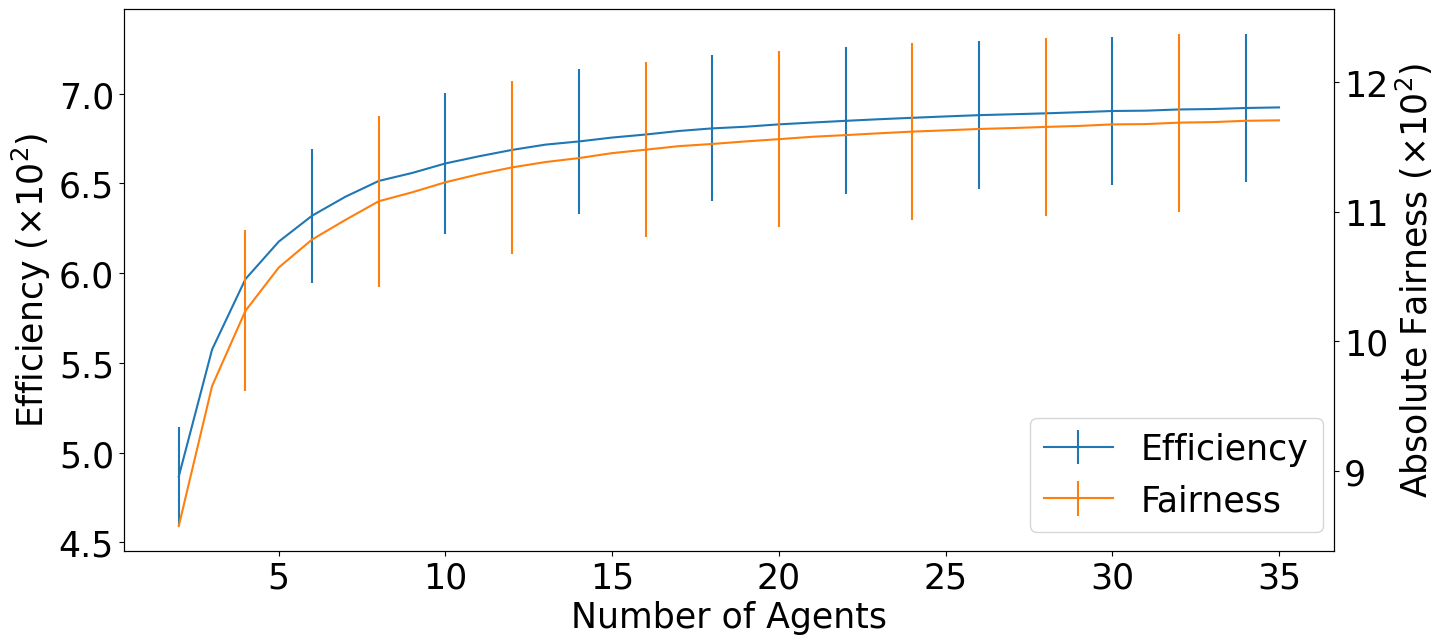

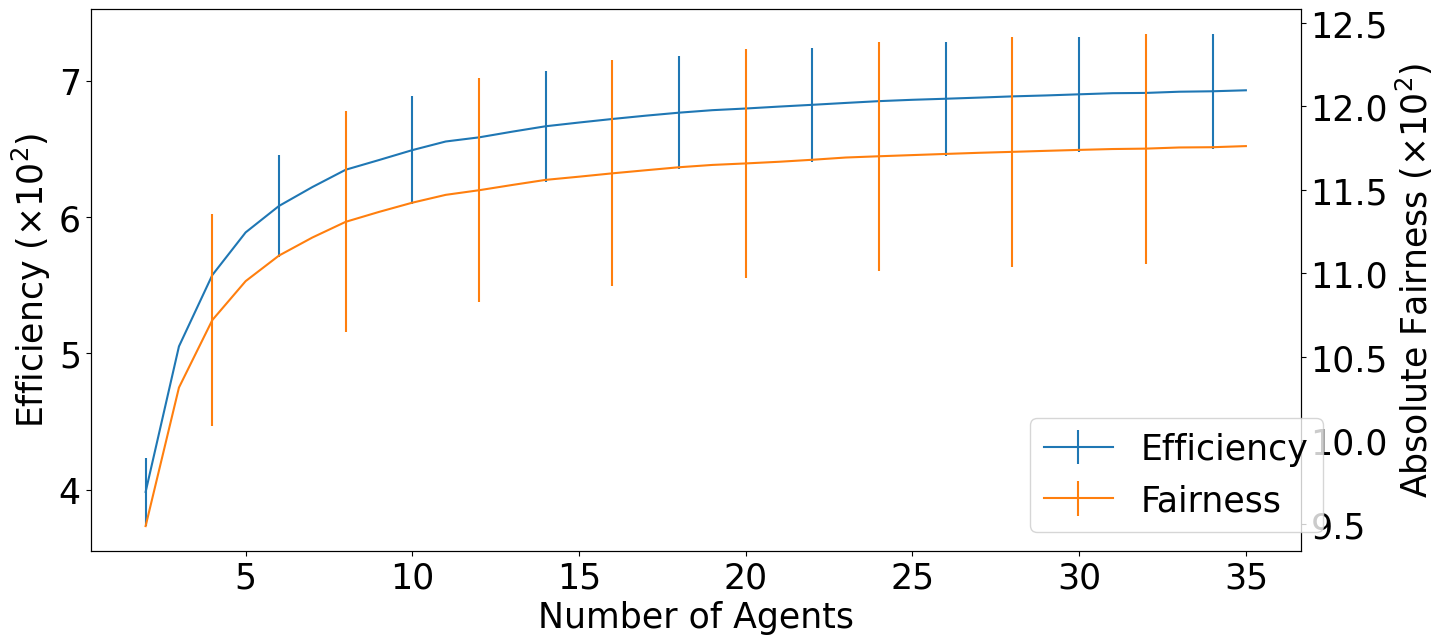

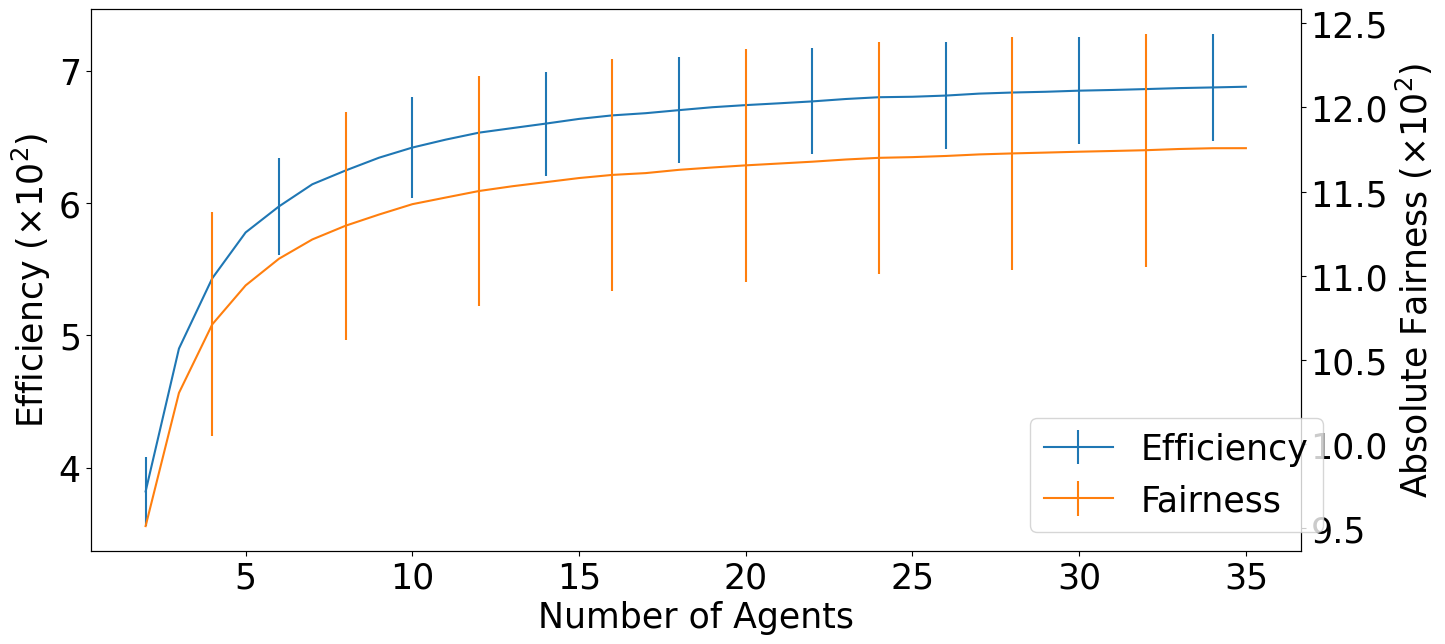

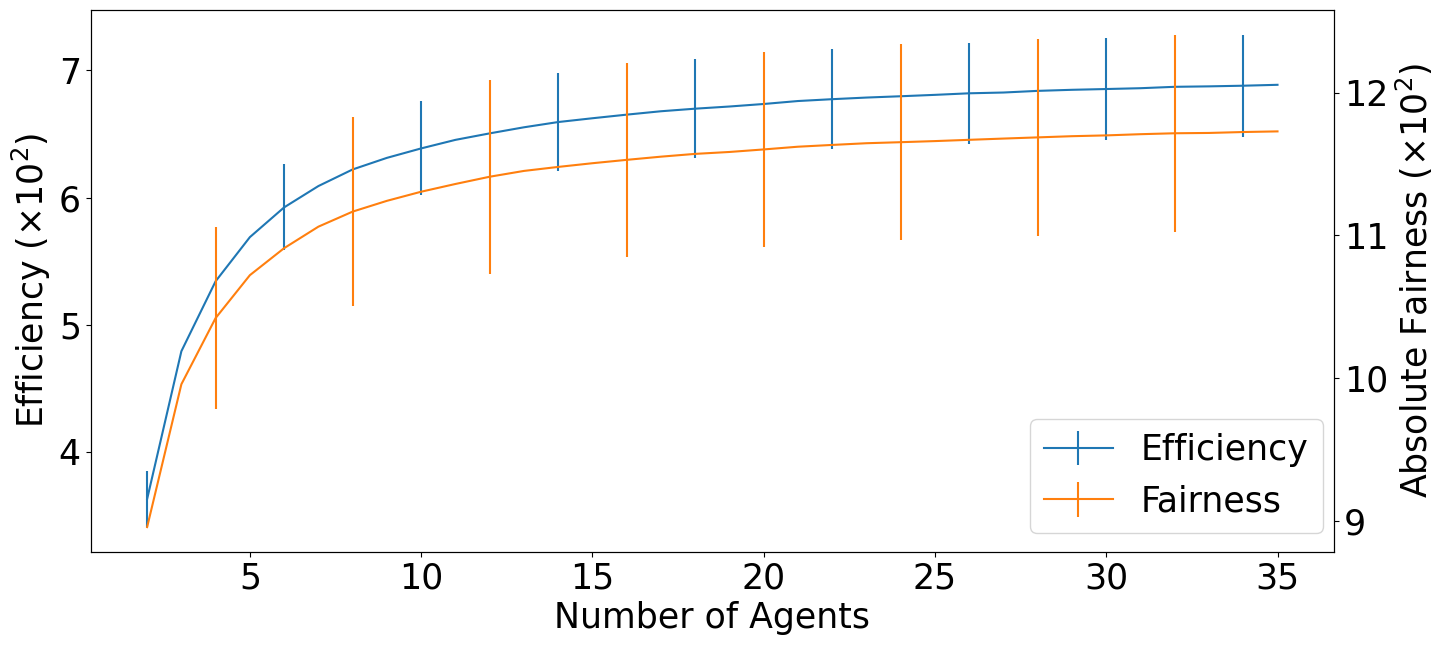

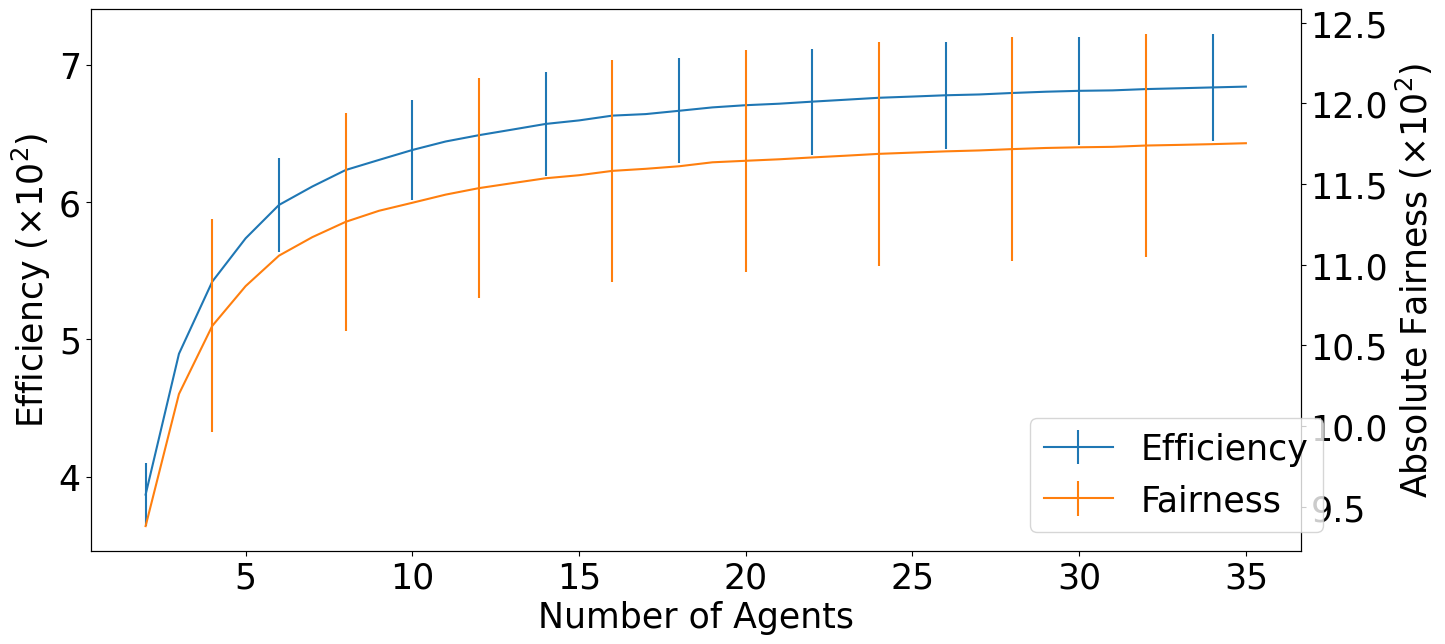

In [44]:
%%time
categorical_n = 36

schedule_metalist = [
    {
        'model':'schenk',
        'path':'./data/schenk/30_dat_{win}.csv',
        'fig':'./figs/schenk_{mod}.pdf',
        'external-scores-path': None
    },
    {
        'model':'sanitarian-blind',
        'path': './data/suppressed_santarian/30_dat_{win}.csv',
        'fig':'./figs/sanitarian-blind_{mod}.pdf',
        'external-scores-path': None
    },
    # extract scores from different files, 
    # add a new column to df and then calculate data-diff
    {
        'model':'zafar',
        'path': './data/schenk/30_dat_{win}.csv',
        'fig':'',
        'external-scores-path': './data/baselines/zafar/zafar_scores_{win}_0.001.csv'
    },
    {
        'model':'rezaei',
        'path': './data/schenk/30_dat_{win}.csv',
        'fig':'',
        'external-scores-path': './data/baselines/rezaei/scores_{win}_eqopp_san_maj_0.5.csv'

    },
    {
        'model':'krishnaswamy',
        'path': './data/schenk/30_dat_{win}.csv',
        'fig':'',
        'external-scores-path': './data/baselines/krishnaswamy/krishnaswamy_preds_{win}.csv'
    }
]

for schedule_info in schedule_metalist:
    schedule_info['result-df-list'] = get_xvalidated_abs_result_df_list(schedule_info['path'], 
                                                                    categorical_n, 
                                                                    schedule_info['external-scores-path'],
                                                                    schedule_info['model'])
    plot_mean_violation(schedule_info['result-df-list'], schedule_info['model'], None)

In [45]:
from mpl_toolkits import mplot3d

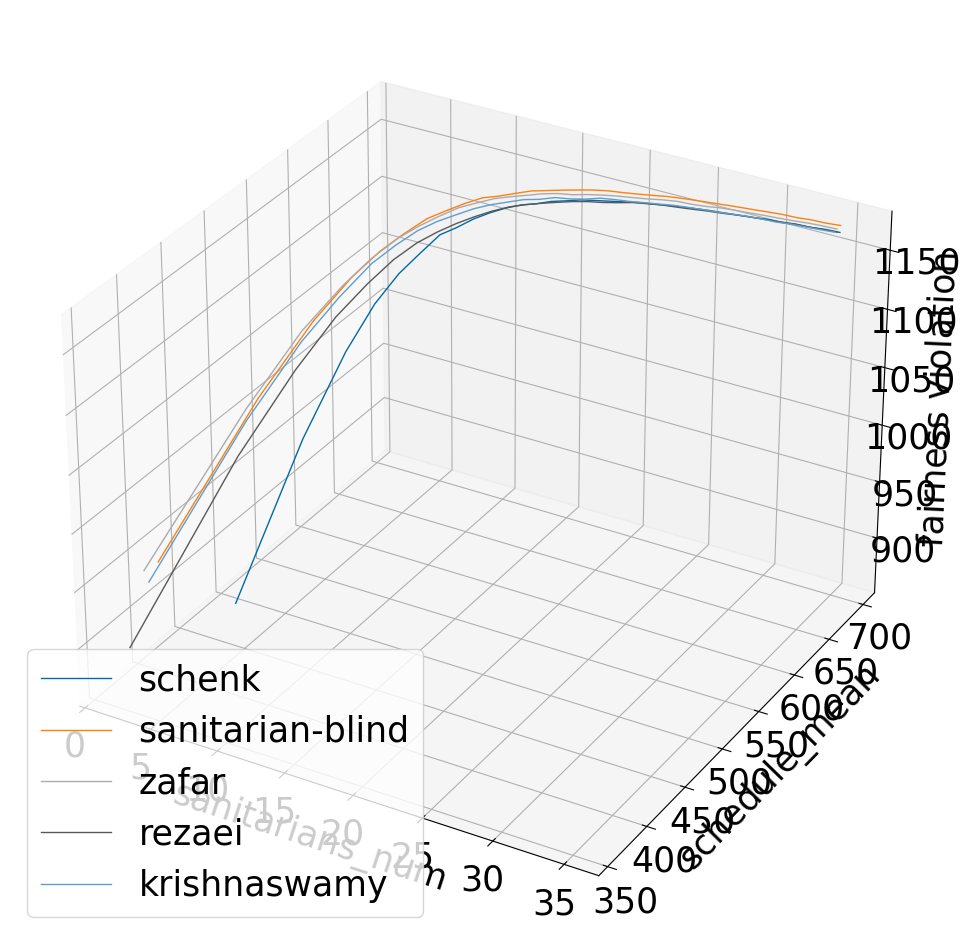

In [46]:
# plt.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection='3d')

for schedule_info in schedule_metalist:
    plot_df_list = [result_df.drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['result-df-list']]
    win_plot_df = pd.concat(plot_df_list)
    gp = win_plot_df.groupby(by=['santarians_num'])
    means = gp.mean(numeric_only=True)
    errors = gp.sem(numeric_only=True)
    ax.plot(means.index, 
            means['schedule_mean'], 
            means['violation'], 
            linewidth=1, label=schedule_info['model'])

# X, Y = np.meshgrid(np.arange(0, 500, 100), np.arange(0, 500, 100))
# Z = 0*X

# ax.plot_surface(X, Y, Z, alpha=0.5)  # the horizontal plane

ax.set_xlabel('sanitarians_num')
ax.set_ylabel('schedule_mean')
ax.set_zlabel('fairness violation')
ax.legend()

# plt.savefig('3d-plot.png', bbox_inches='tight', dpi=300)
# ax.invert_xaxis()
# ax.invert_yaxis()
# plt.savefig('3d-plot-invert-ax.png', bbox_inches='tight', dpi=300)
# ax.set_ylim(350, 0)
# ax.set_xlim(35, 0)
# plt.savefig('3d-plot-limit-ax.png', bbox_inches='tight', dpi=300)

### 2d plot

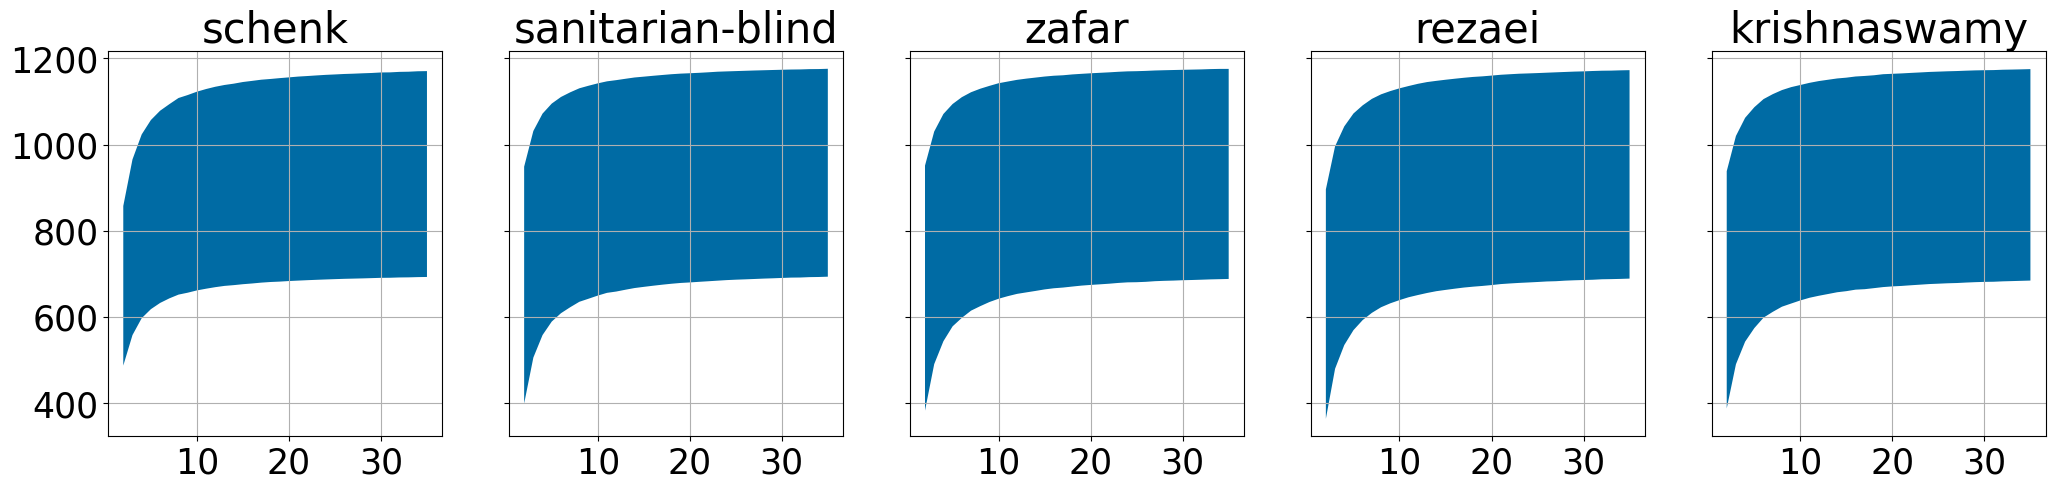

In [47]:
fig, axs = plt.subplots(1, 5, figsize=(25,5), sharey=True)

for i in range(len(schedule_metalist)):
    schedule_info = schedule_metalist[i]
    plot_df_list = [result_df.drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['result-df-list']]
    win_plot_df = pd.concat(plot_df_list)
    gp = win_plot_df.groupby(by=['santarians_num'])
    means = gp.mean(numeric_only=True)
    errors = gp.sem(numeric_only=True)
    axs[i].fill_between(means.index, means['violation'], means['schedule_mean'], 
            linewidth=1)
    axs[i].grid()
    axs[i].set_title(schedule_info['model'])

# ax.set_xlabel('sanitarians_num')
# ax.set_ylabel('schedule_mean - violation')
# plt.grid()
# axs[0].legend()

Text(0, 0.5, 'utility')

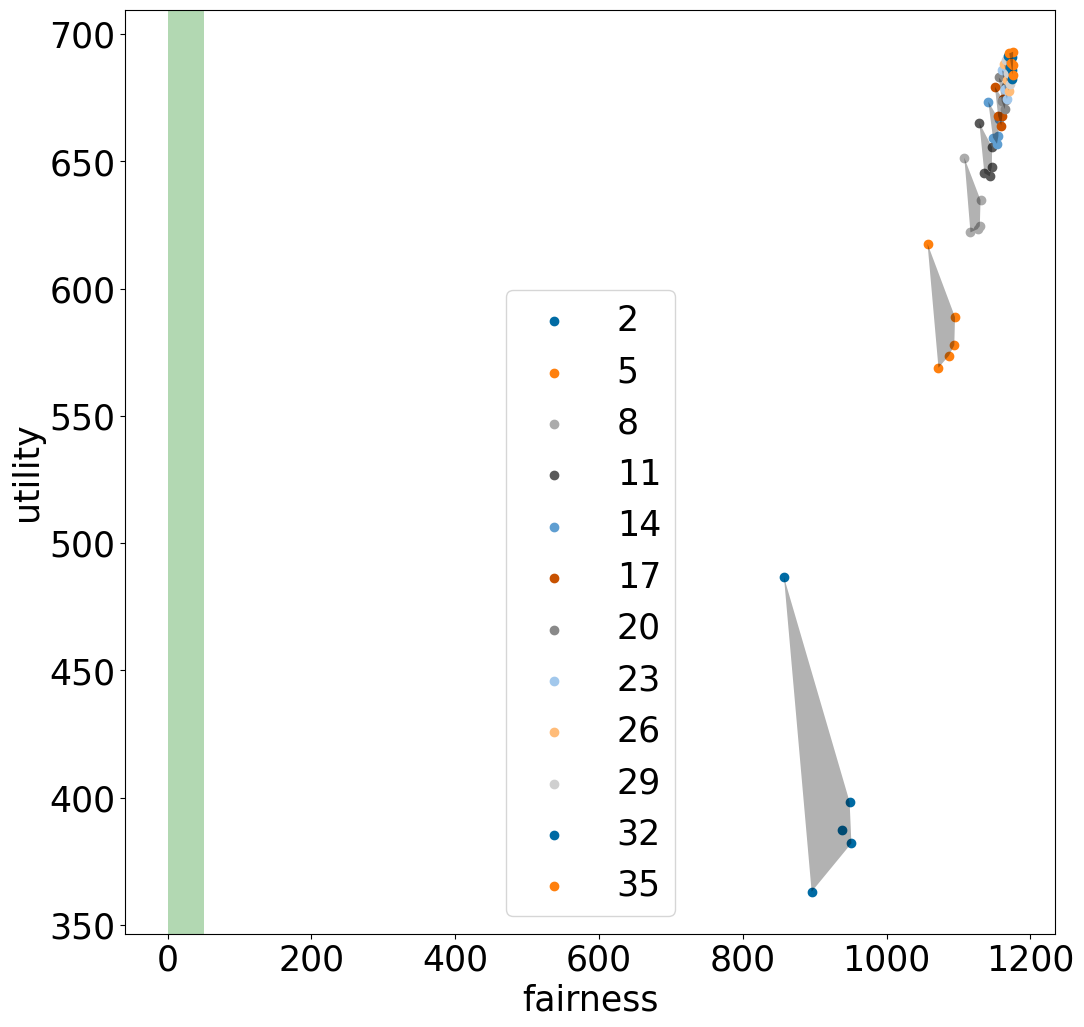

In [48]:
fig, ax = plt.subplots(figsize=(12,12))

for san_ctr in range(2, categorical_n, 3):
    means_list = list()
    errors_list = list()
    for schedule_info in schedule_metalist:
        plot_df_list = [result_df[result_df['santarians_num']==san_ctr].drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['result-df-list']]
        win_plot_df = pd.concat(plot_df_list)
        means_list.append(win_plot_df.mean(numeric_only=True))
        errors_list.append(win_plot_df.sem(numeric_only=True))
    sched_df = pd.concat(means_list, axis=1).T.sort_values(by=['schedule_mean'])
    ax.scatter(sched_df['violation'], sched_df['schedule_mean'], label=san_ctr)
    # plot the convex hull of all the points for that "budget"
    points = np.array(list(sched_df[['violation', 'schedule_mean']].itertuples(index=False, name=None)))
    hull = ConvexHull(points)
    ax.fill(points[hull.vertices,0], points[hull.vertices,1], 'k', alpha=0.3)
ax.axvspan(0, 50, facecolor='green', alpha=0.3)
ax.legend()
ax.set_xlabel('fairness')
ax.set_ylabel('utility')

Text(0, 0.5, 'utility')

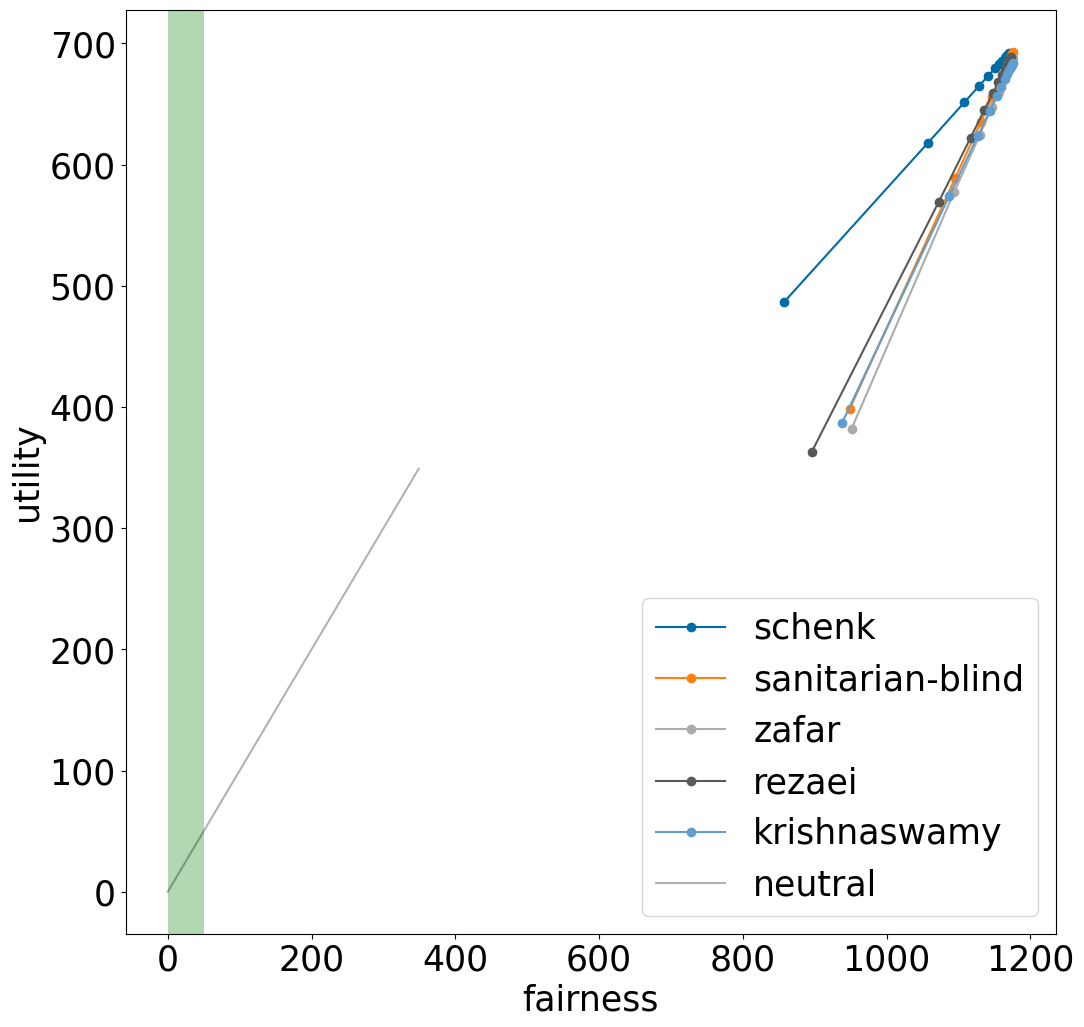

In [49]:
fig, ax = plt.subplots(figsize=(12,12))

for schedule_info in schedule_metalist:
    means_list = list()
    errors_list = list()
    for san_ctr in range(2, categorical_n, 3):
        plot_df_list = [result_df[result_df['santarians_num']==san_ctr].drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['result-df-list']]
        win_plot_df = pd.concat(plot_df_list)
        # print(win_plot_df)
        means_list.append(win_plot_df.mean(numeric_only=True))
        errors_list.append(win_plot_df.sem(numeric_only=True))
    model_df = pd.concat(means_list, axis=1).T.sort_values(by=['schedule_mean'])
    ax.plot(model_df['violation'], model_df['schedule_mean'], '-o', label=schedule_info['model'])
    # ax.scatter(model_df['violation'], model_df['schedule_mean'], label=schedule_info['model'])
ax.plot(np.arange(350), np.arange(350), label='neutral', color='black', alpha=0.3)
ax.axvspan(0, 50, facecolor='green', alpha=0.3)
ax.legend()
ax.set_xlabel('fairness')
ax.set_ylabel('utility')

In [50]:
def add_patch(legend, label_list, marker_list):
    from matplotlib.lines import Line2D
    
    ax = legend.axes

    handles, labels = ax.get_legend_handles_labels()
    for name, marker in zip(label_list, marker_list):
        handles.append(Line2D([0], [0], marker=marker, color='w', 
                              markerfacecolor='tab:gray', markersize=15))
        labels.append(name)

    legend._legend_box = None
    legend._init_legend_box(handles, labels)
    legend._set_loc(legend._loc)
    legend.set_title(legend.get_title().get_text())

price of fairness: 1.2215725870245862, fair: 398.3216344271947, no-fair: 486.5787894350897
price of fairness: 1.0489349151053347, fair: 588.7917745598452, no-fair: 617.6042500626505
price of fairness: 1.0184947965746447, fair: 649.1806995401548, no-fair: 661.1871645183355
price of fairness: 1.0047874374341708, fair: 679.7091148244162, no-fair: 682.9631796850738
price of fairness: 0.9990419412033085, fair: 693.0783774803283, no-fair: 692.4143676439866


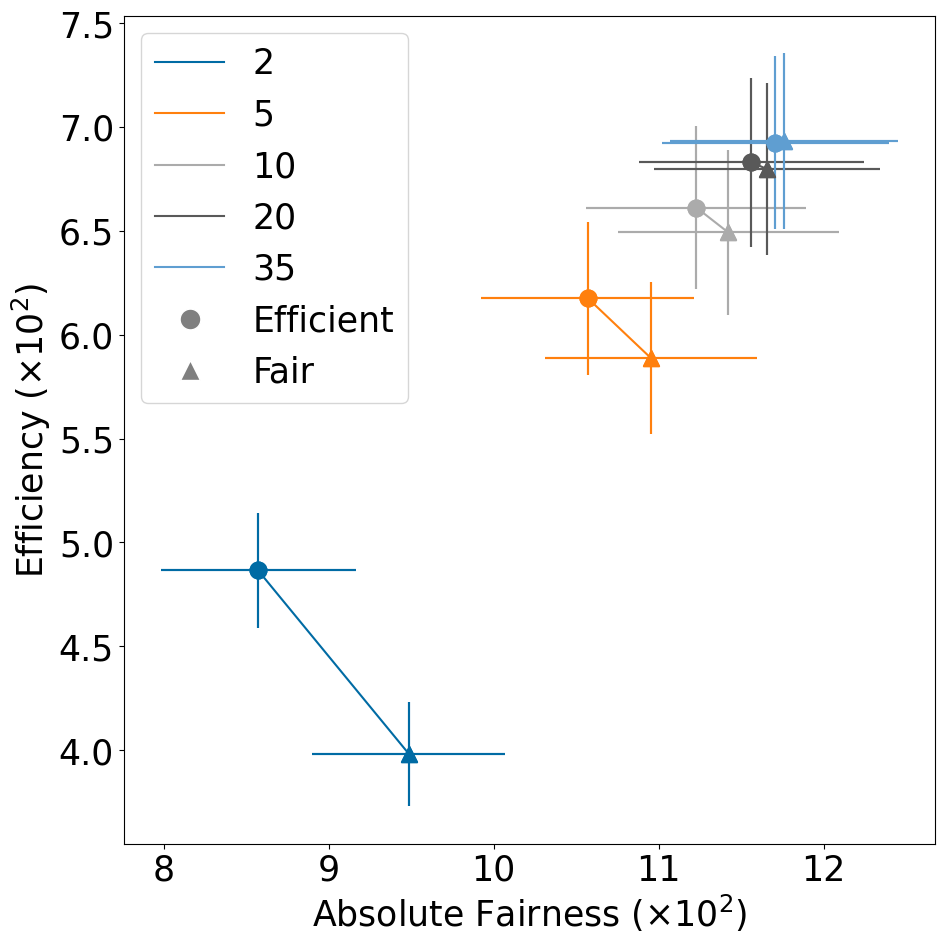

In [51]:
fig, ax = plt.subplots(figsize=(10,10))
plot_list = ['schenk', 'sanitarian-blind']
label_list = ['Efficient', 'Fair']
marker_list = ['o', '^']

# for san_ctr in np.ceil(np.arange(2,8,1) ** 1.8).astype(int):
for san_ctr in [2, 5, 10, 20, 35]:
    means_list = list()
    errors_list = list()
    for schedule_info in schedule_metalist:
        if schedule_info['model'] not in plot_list:
            continue
        plot_df_list = [result_df[result_df['santarians_num']==san_ctr].drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['result-df-list']]
        win_plot_df = pd.concat(plot_df_list)
        means_list.append(win_plot_df.mean(numeric_only=True))
        errors_list.append(win_plot_df.sem(numeric_only=True))
    means_df = pd.concat(means_list, axis=1).T.sort_values(by=['schedule_mean'])
    errors_df = pd.concat(errors_list, axis=1).T.sort_values(by=['schedule_mean'])
    p = ax.plot(means_df['violation']/100, means_df['schedule_mean']/100, label=san_ctr)
    
    for schedule_info in schedule_metalist:
        if schedule_info['model'] not in plot_list:
            continue
        for i in range(len(plot_list)):
            # print(schedule_info['marker'], schedule_info['model'], means_df['violation'][i], means_df['schedule_mean'][i])
            marker = marker_list[i]
            ax.errorbar(means_df['violation'][i]/100, means_df['schedule_mean'][i]/100, xerr=errors_df['violation'][i]/100, yerr=errors_df['schedule_mean'][i]/100,
                            ls='none', color=p[0].get_color(), marker=marker, markersize=12)
            if plot_list[i] == 'schenk':
                no_fair_util = means_df['schedule_mean'][i]
            elif plot_list[i] == 'sanitarian-blind':
                fair_util = means_df['schedule_mean'][i]
    print(f"price of fairness: {no_fair_util/fair_util}, fair: {fair_util}, no-fair: {no_fair_util}")

## vertical line
# ax.axvline(x=11.5, color='gray', ls='--')

y_label = r'Efficiency ($\times 10^2)$' if EFF_VS_COST == 'eff' else r'Cost ($\times 10^2)$'
save_path = f'./figs/efr_abs_{DIST}.pdf' if EFF_VS_COST == 'eff' else f'./figs/cfr_abs_{DIST}.pdf'
ax.set_xlabel(r'Absolute Fairness ($\times 10^2)$')
ax.set_ylabel(y_label)
lgd = ax.legend()
add_patch(lgd, label_list, marker_list)
plt.tight_layout()
plt.savefig(save_path, bbox_inches='tight', dpi=300)

In [52]:
def get_xvalidated_rel_result_df_list(data_home, categorical_n, external_score_path=None, model_name=None):
    result_df_list = list()
    for win in range(19):
        if win in [1,2,3]:
            continue
        df = pd.read_csv(data_home.format(win=win), parse_dates=["Inspection_Date"], dtype=dtype_dict)
        if external_score_path:
            df['glm_pred_test'] = pd.read_csv(external_score_path.format(win=win), header=None)[0]
        result_df = calc_rel_schedule_data(df, insp_per_day_per_sanitarian, categorical_n, group='location') #save_path=f'./sched_modelling/{model_name}_win{win}')
        result_df_list.append(result_df)
    return result_df_list

In [53]:
for schedule_info in schedule_metalist:
    schedule_info['rel-result-df-list'] = get_xvalidated_rel_result_df_list(schedule_info['path'], 
                                                                    categorical_n, 
                                                                    schedule_info['external-scores-path'],
                                                                    schedule_info['model'])

In [54]:
def plot_mean_violation(result_df_list, title, save_path):
    plot_df_list = [result_df.drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in result_df_list]
    win_plot_df = pd.concat(plot_df_list)
    gp = win_plot_df.groupby(by=['santarians_num'])
    means = gp.mean(numeric_only=True)
    errors = gp.sem(numeric_only=True)
    
    fig, ax = plt.subplots(figsize=(15,7))
    ax_t = ax.twinx() 
    
    w=0.3
    # means['schedule_mean'].plot.bar(yerr=errors['schedule_mean'], width=w, ax=ax, rot=0, position=1, color='tab:blue')
    # means['violation'].plot.bar(yerr=errors['violation'], width=w, ax=ax_t, rot=0, position=0, color='tab:orange')
    ax.errorbar(means.index, means['schedule_mean']/100, yerr=errors['schedule_mean']/100, errorevery=(0, 4), color='tab:blue', label="Efficiency")
    ax_t.errorbar(means.index, means['violation'], yerr=errors['violation'], errorevery=(2, 4), color='tab:orange', label="Fairness")
    y_label = r'Efficiency ($\times 10^2)$' if EFF_VS_COST == 'eff' else r'Cost ($\times 10^2)$'
    ax.set_ylabel(y_label)
    ax_t.set_ylabel(r'Relative Fairness')
    ax.set_xlabel('Number of Agents')
    # ax.set_title(title)
    fig.legend(bbox_to_anchor=(0.85, 0.2), loc='lower right', borderaxespad=0)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

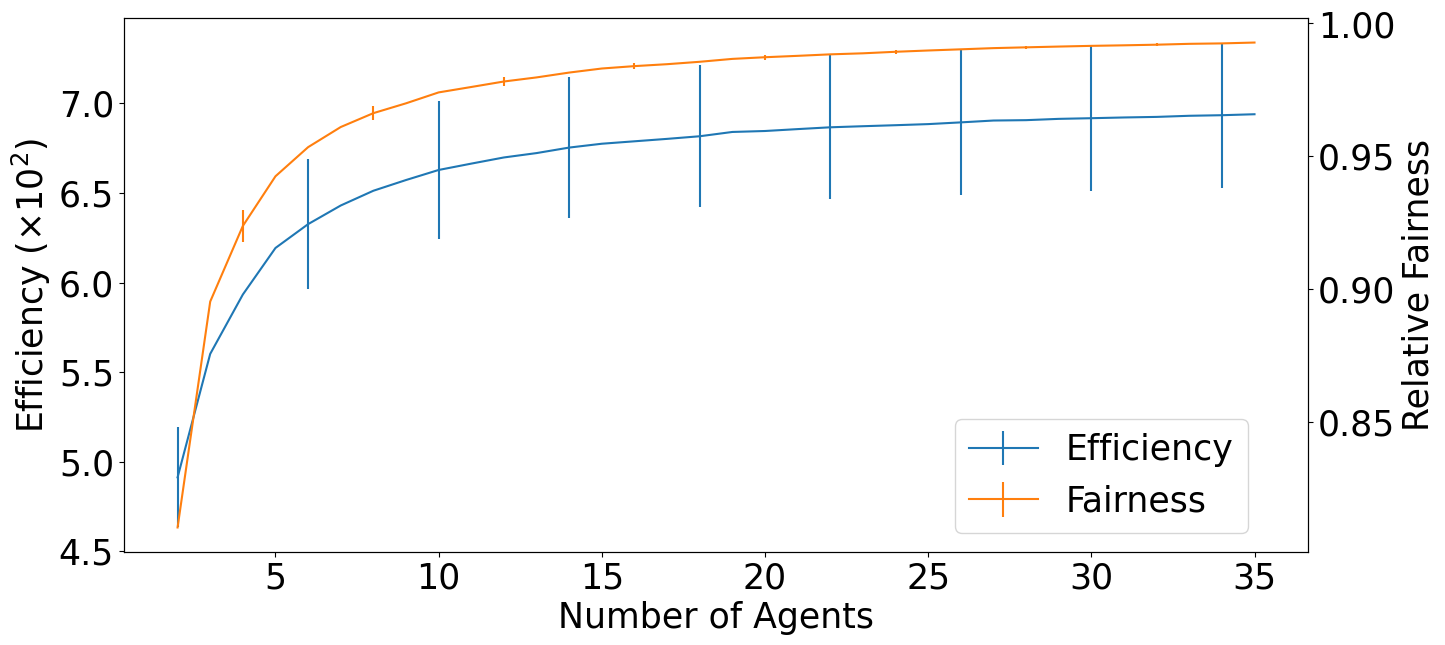

In [55]:
for schedule_info in schedule_metalist:
    plot_mean_violation(schedule_info['rel-result-df-list'], schedule_info['model'], None)
    break

price of fairness: 1.2430437877597913, fair: 395.24766936909646, no-fair: 491.31016003579134
price of fairness: 1.072461794520461, fair: 577.4345694083745, no-fair: 619.2765145258551
price of fairness: 1.038905747308778, fair: 637.9680281675687, no-fair: 662.7886510625355
price of fairness: 1.0225608631364245, fair: 669.4250792335403, no-fair: 684.5278868262183
price of fairness: 1.0164239348645352, fair: 682.667172774626, no-fair: 693.8792539544329


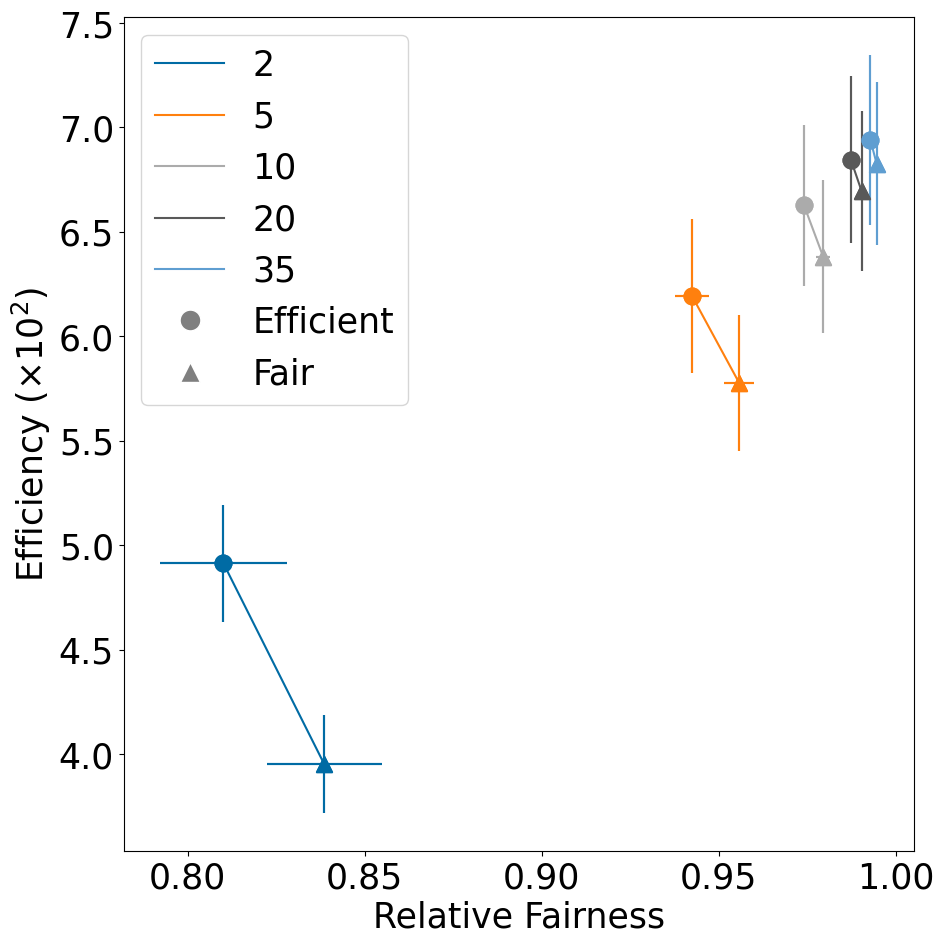

In [56]:
fig, ax = plt.subplots(figsize=(10,10))
plot_list = ['schenk', 'sanitarian-blind']
label_list = ['Efficient', 'Fair']
marker_list = ['o', '^',]

# for san_ctr in np.ceil(np.arange(2,8,1) ** 1.8).astype(int):
for san_ctr in [2, 5, 10, 20, 35]:
    means_list = list()
    errors_list = list()
    for schedule_info in schedule_metalist:
        if schedule_info['model'] not in plot_list:
            continue
        plot_df_list = [result_df[result_df['santarians_num']==san_ctr].drop_duplicates(subset=['santarians_num']).set_index('santarians_num') for result_df in schedule_info['rel-result-df-list']]
        win_plot_df = pd.concat(plot_df_list)
        means_list.append(win_plot_df.mean(numeric_only=True))
        errors_list.append(win_plot_df.sem(numeric_only=True))
    means_df = pd.concat(means_list, axis=1).T.sort_values(by=['schedule_mean'])
    errors_df = pd.concat(errors_list, axis=1).T.sort_values(by=['schedule_mean'])
    p = ax.plot(means_df['violation'], means_df['schedule_mean']/100, label=san_ctr)
    
    for schedule_info in schedule_metalist:
        if schedule_info['model'] not in plot_list:
            continue
        for i in range(len(plot_list)):
            # print(schedule_info['marker'], schedule_info['model'], means_df['violation'][i], means_df['schedule_mean'][i])
            marker = marker_list[i]
            ax.errorbar(means_df['violation'][i], means_df['schedule_mean'][i]/100, xerr=errors_df['violation'][i], yerr=errors_df['schedule_mean'][i]/100,
                            ls='none', color=p[0].get_color(), marker=marker, markersize=12)
            if plot_list[i] == 'schenk':
                no_fair_util = means_df['schedule_mean'][i]
            elif plot_list[i] == 'sanitarian-blind':
                fair_util = means_df['schedule_mean'][i]
    print(f"price of fairness: {no_fair_util/fair_util}, fair: {fair_util}, no-fair: {no_fair_util}")
    
y_label = r'Efficiency ($\times 10^2)$' if EFF_VS_COST == 'eff' else r'Cost ($\times 10^2)$'
save_path = f'./figs/efr_rel_{DIST}.pdf' if EFF_VS_COST == 'eff' else f'./figs/cfr_rel_{DIST}.pdf'

ax.set_xlabel(r'Relative Fairness')
ax.set_ylabel(y_label)
lgd = ax.legend()
add_patch(lgd, label_list, marker_list)
plt.tight_layout()
plt.savefig(save_path, bbox_inches='tight', dpi=300)